# Lab: Text Preprocessing

In this lab, we will explore how raw text is prepared before being used.

Search engines and retrieval systems do not use raw text directly.  
Instead, they apply several preprocessing steps to clean, normalize, and standardize the text.

In this lab, we will:

1. Load raw text
2. Normalize text (lowercasing & cleaning)
3. Tokenize text
4. Remove stopwords
5. Apply stemming
6. Apply lemmatization
7. Compare results

The goal is to clearly understand what each step does and why it is important.

## **Import Libraries**

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mezom\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mezom\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mezom\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## **Loading Raw Text**

The first step in preprocessing is loading the document.

At this stage, the text is completely raw:
- It contains uppercase and lowercase letters
- It contains punctuation
- It may contain numbers
- It has not been cleaned or structured

This is how documents usually exist before preprocessing.

In [88]:
with open('Essay.txt') as f:
    lines = f.readlines()

print(lines)

['Education means considerably more than just teaching a student to read, write, and manipulate numbers. Computers, the Internet, and advanced electronic devices are becoming essential in everyday life and have changed the way information is gathered. How this new technology is utilized in the curriculum and managed by teachers will have an important role to play in widening the resource and knowledge base for all students. Technology affects the way teachers teach and students learn. To make the best use of information technology (IT), schools need a workable plan to fully integrate it into all aspects of the curriculum so students are taught how, why, and when to use technology to further enhance their learning. If a school does not have a clear plan of how and why it wishes to implement IT, then it runs the risk of wasting money. In schools today, nearly all classrooms have access to a computer.']


## **Text Normalization**

Text normalization makes the text consistent.

Why is this important?

If we do not normalize:
- "Information" and "information" would be treated as different words.
- Punctuation marks would be considered tokens.
- Vocabulary size would increase unnecessarily.

Normalization reduces noise and helps standardize terms.

In [89]:
text_lower = lines[0].lower()
print(text_lower)

education means considerably more than just teaching a student to read, write, and manipulate numbers. computers, the internet, and advanced electronic devices are becoming essential in everyday life and have changed the way information is gathered. how this new technology is utilized in the curriculum and managed by teachers will have an important role to play in widening the resource and knowledge base for all students. technology affects the way teachers teach and students learn. to make the best use of information technology (it), schools need a workable plan to fully integrate it into all aspects of the curriculum so students are taught how, why, and when to use technology to further enhance their learning. if a school does not have a clear plan of how and why it wishes to implement it, then it runs the risk of wasting money. in schools today, nearly all classrooms have access to a computer.


In [90]:
print(re.findall(r'[\d]', text_lower))

[]


In [91]:
print(re.findall(r'[^\w\s]', text_lower))

[',', ',', '.', ',', ',', '.', '.', '.', '(', ')', ',', ',', ',', '.', ',', '.', ',', '.']


In [92]:
text_clean = re.sub(r'[^\w\s]', '', text_lower)
print(text_clean)

education means considerably more than just teaching a student to read write and manipulate numbers computers the internet and advanced electronic devices are becoming essential in everyday life and have changed the way information is gathered how this new technology is utilized in the curriculum and managed by teachers will have an important role to play in widening the resource and knowledge base for all students technology affects the way teachers teach and students learn to make the best use of information technology it schools need a workable plan to fully integrate it into all aspects of the curriculum so students are taught how why and when to use technology to further enhance their learning if a school does not have a clear plan of how and why it wishes to implement it then it runs the risk of wasting money in schools today nearly all classrooms have access to a computer


## **Tokenization**

Tokenization is the process of breaking text into smaller units called tokens.

This step is critical because:
- The index is built on tokens
- Searching is performed over tokens

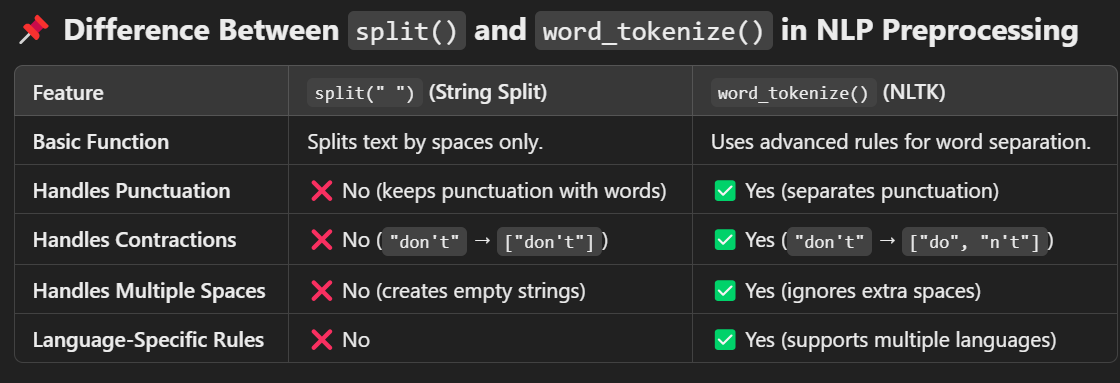

In [93]:
tokens = text_lower.split(' ')
print(tokens)
print(len(tokens))

['education', 'means', 'considerably', 'more', 'than', 'just', 'teaching', 'a', 'student', 'to', 'read,', 'write,', 'and', 'manipulate', 'numbers.', 'computers,', 'the', 'internet,', 'and', 'advanced', 'electronic', 'devices', 'are', 'becoming', 'essential', 'in', 'everyday', 'life', 'and', 'have', 'changed', 'the', 'way', 'information', 'is', 'gathered.', 'how', 'this', 'new', 'technology', 'is', 'utilized', 'in', 'the', 'curriculum', 'and', 'managed', 'by', 'teachers', 'will', 'have', 'an', 'important', 'role', 'to', 'play', 'in', 'widening', 'the', 'resource', 'and', 'knowledge', 'base', 'for', 'all', 'students.', 'technology', 'affects', 'the', 'way', 'teachers', 'teach', 'and', 'students', 'learn.', 'to', 'make', 'the', 'best', 'use', 'of', 'information', 'technology', '(it),', 'schools', 'need', 'a', 'workable', 'plan', 'to', 'fully', 'integrate', 'it', 'into', 'all', 'aspects', 'of', 'the', 'curriculum', 'so', 'students', 'are', 'taught', 'how,', 'why,', 'and', 'when', 'to', 'us

In [94]:
tokens = word_tokenize(text_lower)
print(tokens)
print(len(tokens))

['education', 'means', 'considerably', 'more', 'than', 'just', 'teaching', 'a', 'student', 'to', 'read', ',', 'write', ',', 'and', 'manipulate', 'numbers', '.', 'computers', ',', 'the', 'internet', ',', 'and', 'advanced', 'electronic', 'devices', 'are', 'becoming', 'essential', 'in', 'everyday', 'life', 'and', 'have', 'changed', 'the', 'way', 'information', 'is', 'gathered', '.', 'how', 'this', 'new', 'technology', 'is', 'utilized', 'in', 'the', 'curriculum', 'and', 'managed', 'by', 'teachers', 'will', 'have', 'an', 'important', 'role', 'to', 'play', 'in', 'widening', 'the', 'resource', 'and', 'knowledge', 'base', 'for', 'all', 'students', '.', 'technology', 'affects', 'the', 'way', 'teachers', 'teach', 'and', 'students', 'learn', '.', 'to', 'make', 'the', 'best', 'use', 'of', 'information', 'technology', '(', 'it', ')', ',', 'schools', 'need', 'a', 'workable', 'plan', 'to', 'fully', 'integrate', 'it', 'into', 'all', 'aspects', 'of', 'the', 'curriculum', 'so', 'students', 'are', 'taugh

## **Sentence Tokenizer**

In [95]:
sentences = text_lower.split('.')
sentences

['education means considerably more than just teaching a student to read, write, and manipulate numbers',
 ' computers, the internet, and advanced electronic devices are becoming essential in everyday life and have changed the way information is gathered',
 ' how this new technology is utilized in the curriculum and managed by teachers will have an important role to play in widening the resource and knowledge base for all students',
 ' technology affects the way teachers teach and students learn',
 ' to make the best use of information technology (it), schools need a workable plan to fully integrate it into all aspects of the curriculum so students are taught how, why, and when to use technology to further enhance their learning',
 ' if a school does not have a clear plan of how and why it wishes to implement it, then it runs the risk of wasting money',
 ' in schools today, nearly all classrooms have access to a computer',
 '']

In [96]:
tokenized_text = sent_tokenize(text_lower)
print(tokenized_text)

['education means considerably more than just teaching a student to read, write, and manipulate numbers.', 'computers, the internet, and advanced electronic devices are becoming essential in everyday life and have changed the way information is gathered.', 'how this new technology is utilized in the curriculum and managed by teachers will have an important role to play in widening the resource and knowledge base for all students.', 'technology affects the way teachers teach and students learn.', 'to make the best use of information technology (it), schools need a workable plan to fully integrate it into all aspects of the curriculum so students are taught how, why, and when to use technology to further enhance their learning.', 'if a school does not have a clear plan of how and why it wishes to implement it, then it runs the risk of wasting money.', 'in schools today, nearly all classrooms have access to a computer.']


## **Stopword Removal**

Stopwords are very common words such as:
- the
- is
- of
- in
- and

These words appear very frequently but usually carry little meaning.

Removing stopwords:
- Reduces index size
- Improves efficiency
- Keeps more meaningful words

In [97]:
stop_words = set(stopwords.words('english'))

filtered_tokens = [word for word in tokens if word not in stop_words]

print(filtered_tokens)

['education', 'means', 'considerably', 'teaching', 'student', 'read', ',', 'write', ',', 'manipulate', 'numbers', '.', 'computers', ',', 'internet', ',', 'advanced', 'electronic', 'devices', 'becoming', 'essential', 'everyday', 'life', 'changed', 'way', 'information', 'gathered', '.', 'new', 'technology', 'utilized', 'curriculum', 'managed', 'teachers', 'important', 'role', 'play', 'widening', 'resource', 'knowledge', 'base', 'students', '.', 'technology', 'affects', 'way', 'teachers', 'teach', 'students', 'learn', '.', 'make', 'best', 'use', 'information', 'technology', '(', ')', ',', 'schools', 'need', 'workable', 'plan', 'fully', 'integrate', 'aspects', 'curriculum', 'students', 'taught', ',', ',', 'use', 'technology', 'enhance', 'learning', '.', 'school', 'clear', 'plan', 'wishes', 'implement', ',', 'runs', 'risk', 'wasting', 'money', '.', 'schools', 'today', ',', 'nearly', 'classrooms', 'access', 'computer', '.']


Let us compare the number of tokens before and after stopword removal.

In [98]:
print("Before stopword removal:", len(tokens))
print("After stopword removal:", len(filtered_tokens))

Before stopword removal: 170
After stopword removal: 95


## **Stemming**

Stemming reduces words to their root form by removing suffixes.

Example:
- processing → process
- documents → document

Stemming:
- Is fast
- Does not consider grammar
- May produce non-real words

It helps increase recall in IR systems.

In [99]:
stemmer = PorterStemmer()

stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]

print(stemmed_tokens)

['educ', 'mean', 'consider', 'teach', 'student', 'read', ',', 'write', ',', 'manipul', 'number', '.', 'comput', ',', 'internet', ',', 'advanc', 'electron', 'devic', 'becom', 'essenti', 'everyday', 'life', 'chang', 'way', 'inform', 'gather', '.', 'new', 'technolog', 'util', 'curriculum', 'manag', 'teacher', 'import', 'role', 'play', 'widen', 'resourc', 'knowledg', 'base', 'student', '.', 'technolog', 'affect', 'way', 'teacher', 'teach', 'student', 'learn', '.', 'make', 'best', 'use', 'inform', 'technolog', '(', ')', ',', 'school', 'need', 'workabl', 'plan', 'fulli', 'integr', 'aspect', 'curriculum', 'student', 'taught', ',', ',', 'use', 'technolog', 'enhanc', 'learn', '.', 'school', 'clear', 'plan', 'wish', 'implement', ',', 'run', 'risk', 'wast', 'money', '.', 'school', 'today', ',', 'nearli', 'classroom', 'access', 'comput', '.']


## **Lemmatization**

Lemmatization reduces words to their dictionary base form.

Unlike stemming:
- It considers vocabulary
- It produces real words
- It is more accurate but slightly slower

Example:
- running → run
- better → good (if part-of-speech is specified)

In [100]:
lemmatizer = WordNetLemmatizer()

lemmatized_tokens = [lemmatizer.lemmatize(word) for word in filtered_tokens]

print(lemmatized_tokens)

['education', 'mean', 'considerably', 'teaching', 'student', 'read', ',', 'write', ',', 'manipulate', 'number', '.', 'computer', ',', 'internet', ',', 'advanced', 'electronic', 'device', 'becoming', 'essential', 'everyday', 'life', 'changed', 'way', 'information', 'gathered', '.', 'new', 'technology', 'utilized', 'curriculum', 'managed', 'teacher', 'important', 'role', 'play', 'widening', 'resource', 'knowledge', 'base', 'student', '.', 'technology', 'affect', 'way', 'teacher', 'teach', 'student', 'learn', '.', 'make', 'best', 'use', 'information', 'technology', '(', ')', ',', 'school', 'need', 'workable', 'plan', 'fully', 'integrate', 'aspect', 'curriculum', 'student', 'taught', ',', ',', 'use', 'technology', 'enhance', 'learning', '.', 'school', 'clear', 'plan', 'wish', 'implement', ',', 'run', 'risk', 'wasting', 'money', '.', 'school', 'today', ',', 'nearly', 'classroom', 'access', 'computer', '.']


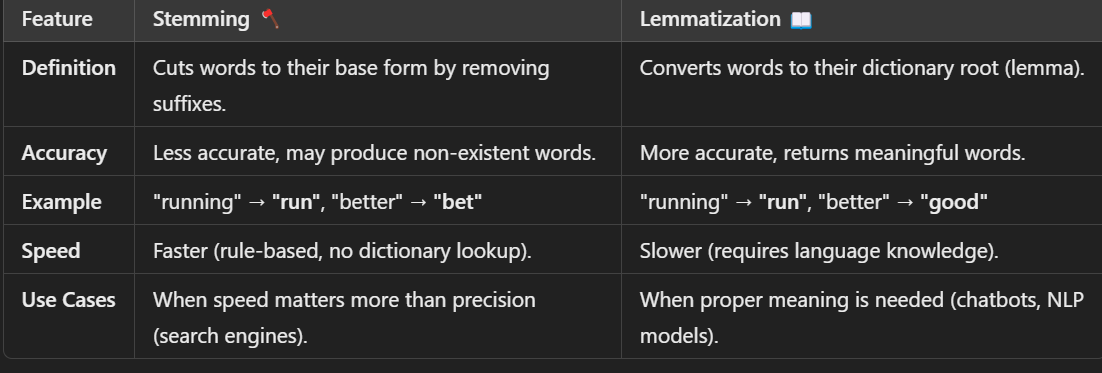

## **Comparing Stemming and Lemmatization**

Let us compare how both techniques handle the same word.

In [101]:
example_word = "processing"

print("Original:", example_word)
print("Stemmed:", stemmer.stem(example_word))
print("Lemmatized:", lemmatizer.lemmatize(example_word, 'v'))

Original: processing
Stemmed: process
Lemmatized: process


## **Final Preprocessing Pipeline**

Now we combine all steps into one function.

This simulates what happens inside an Information Retrieval system 
before indexing documents.

In [102]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    
    return tokens

processed_text = preprocess(lines[0])
print(processed_text)
print("Original token count:", len(word_tokenize(lines[0])))
print("Processed token count:", len(processed_text))

['education', 'mean', 'considerably', 'teaching', 'student', 'read', 'write', 'manipulate', 'number', 'computer', 'internet', 'advanced', 'electronic', 'device', 'becoming', 'essential', 'everyday', 'life', 'changed', 'way', 'information', 'gathered', 'new', 'technology', 'utilized', 'curriculum', 'managed', 'teacher', 'important', 'role', 'play', 'widening', 'resource', 'knowledge', 'base', 'student', 'technology', 'affect', 'way', 'teacher', 'teach', 'student', 'learn', 'make', 'best', 'use', 'information', 'technology', 'school', 'need', 'workable', 'plan', 'fully', 'integrate', 'aspect', 'curriculum', 'student', 'taught', 'use', 'technology', 'enhance', 'learning', 'school', 'clear', 'plan', 'wish', 'implement', 'run', 'risk', 'wasting', 'money', 'school', 'today', 'nearly', 'classroom', 'access', 'computer']
Original token count: 170
Processed token count: 77
